In [1]:
#pip install beautifulsoup4 requests lxml pandas matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 19.8 MB/s  0:00:00 eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [27]:
from bs4 import BeautifulSoup
import requests
import json
import pandas as pd
import matplotlib.pyplot as plt

In [28]:
import os
os.getcwd()
with open("enchantedscrunch.html", "r", encoding="utf-8") as f:
    html = f.read()


In [29]:
soup = BeautifulSoup(html, "lxml")

In [31]:
script_tag = soup.find("script", id="__NEXT_DATA__", type="application/json")

if script_tag is None:
    print("Could not find the __NEXT_DATA__ script tag. Check your file.")
else:
    json_text = script_tag.string  


In [32]:
data = json.loads(json_text)

In [33]:

user_info = data["props"]["pageProps"]["trpcState"]["json"]["queries"][1]["state"]["data"]
print(user_info["username"])
print(user_info["followers"])
print(user_info["likes"])


enchantedscrunch
507000
20300000


In [34]:
print(data.keys())

print(data["props"].keys())
print(data["props"]["pageProps"].keys())
print(data["props"]["pageProps"]["trpcState"].keys())
print(data["props"]["pageProps"]["trpcState"]["json"].keys())

queries = data["props"]["pageProps"]["trpcState"]["json"]["queries"]
for i, q in enumerate(queries):
    print(i, q["queryKey"])



dict_keys(['props', 'page', 'query', 'buildId', 'isFallback', 'isExperimentalCompile', 'appGip', 'scriptLoader'])
dict_keys(['pageProps'])
dict_keys(['trpcState'])
dict_keys(['json', 'meta'])
dict_keys(['mutations', 'queries'])
0 [['auth', 'account', 'me'], {'type': 'query'}]
1 [['tiktok', 'user'], {'input': {'id': 'enchantedscrunch'}, 'type': 'query'}]
2 [['exchangeRates'], {'type': 'query'}]
3 [['tiktok', 'history'], {'input': {'id': '6949195484124677126', 'limit': 15}, 'type': 'query'}]
4 [['account', 'billing', 'plans'], {'type': 'query'}]


In [35]:
with open("enchantedscrunch.html", "r", encoding="utf-8") as f:
    html = f.read()
soup = BeautifulSoup(html, "lxml")
table = soup.find("table")  
df = pd.read_html(str(table))[0]
df.head()

/var/folders/rd/n19jdt9x1lgb3w20fckdfv6h0000gn/T/ipykernel_1226/3357554995.py:11: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_html(str(table))[0]


,Date,followers,followers.1,following,following.1,likes,likes.1,videos,videos.1
0,Sat2025-09-13,--,507300,--,630,--,20200000,--,2651
1,Sun2025-09-14,-100,507200,--,630,--,20200000,1,2652
2,Mon2025-09-15,--,507200,--,630,--,20200000,--,2652
3,Tue2025-09-16,-100,507100,1,631,--,20200000,--,2652
4,Wed2025-09-17,--,507100,1,632,--,20200000,2,2654


In [37]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', None)

df


,Date,followers,followers.1,following,following.1,likes,likes.1,videos,videos.1,gained_followers,gained_likes
0,2025-09-13,NaN,507300,NaN,630,NaN,20200000,NaN,2651,NaN,NaN
1,2025-09-14,-100.0,507200,NaN,630,NaN,20200000,1.0,2652,NaN,NaN
2,2025-09-15,NaN,507200,NaN,630,NaN,20200000,NaN,2652,NaN,NaN
3,2025-09-16,-100.0,507100,1.0,631,NaN,20200000,NaN,2652,NaN,NaN
4,2025-09-17,NaN,507100,1.0,632,NaN,20200000,2.0,2654,NaN,NaN
5,2025-09-18,NaN,507100,NaN,632,NaN,20200000,1.0,2655,NaN,NaN
6,2025-09-19,100.0,507200,1.0,633,NaN,20200000,1.0,2656,NaN,NaN
7,2025-09-20,NaN,507200,NaN,633,NaN,20200000,1.0,2657,NaN,NaN
8,2025-09-21,NaN,507200,3.0,636,100000.0,20300000,NaN,2657,NaN,NaN
9,2025-09-22,100.0,507300,NaN,636,NaN,20300000,NaN,2657,NaN,NaN


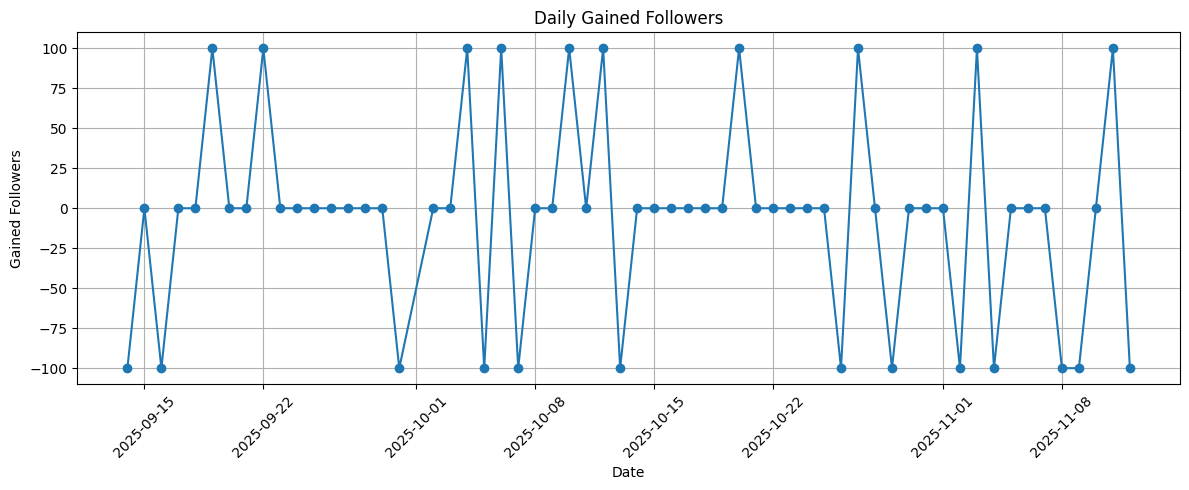

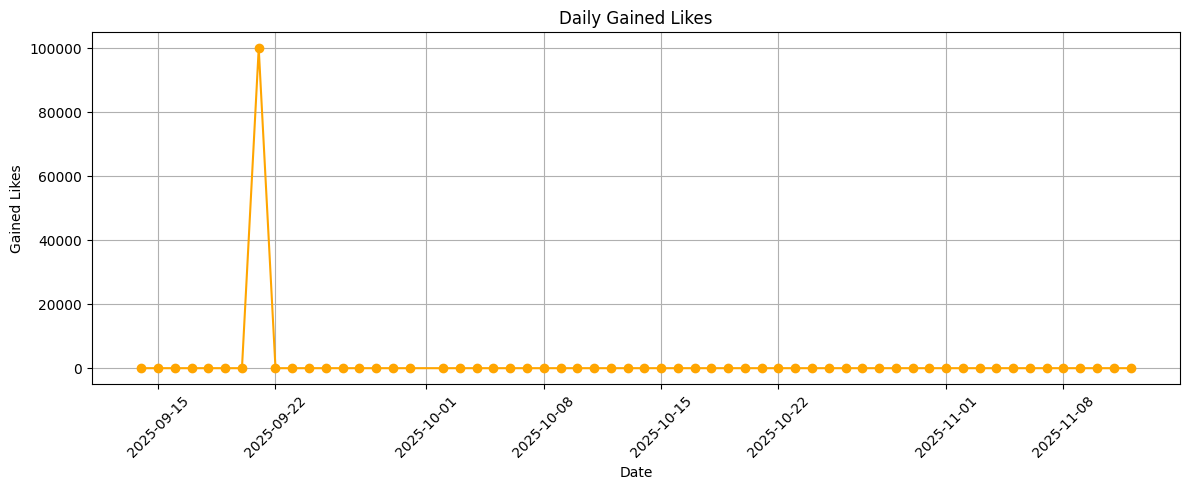

In [39]:
df_clean = df[['Date', 'followers.1', 'likes.1']].copy()
df_clean.columns = ['Date', 'Followers', 'Likes'] 

df_clean['Date'] = pd.to_datetime(df_clean['Date'], errors='coerce')

df_clean['Followers'] = pd.to_numeric(df_clean['Followers'], errors='coerce')
df_clean['Likes'] = pd.to_numeric(df_clean['Likes'], errors='coerce')
df_clean = df_clean.dropna(subset=['Date', 'Followers', 'Likes'])
df_clean['Gained_Followers'] = df_clean['Followers'].diff()
df_clean['Gained_Likes'] = df_clean['Likes'].diff()
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df_clean['Date'], df_clean['Gained_Followers'], marker='o')
plt.title('Daily Gained Followers')
plt.xlabel('Date')
plt.ylabel('Gained Followers')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(df_clean['Date'], df_clean['Gained_Likes'], marker='o', color='orange')
plt.title('Daily Gained Likes')
plt.xlabel('Date')
plt.ylabel('Gained Likes')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()
